In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
#| default_exp tonegen

In [ ]:
#| export
from tone_datagen.tone_element import tone

In [ ]:
list(tone(20, -3, 0.3, 0.2, 0.5, 0.1, rate=15))

[0.0,
 0.0,
 -0.0,
 -0.0,
 0.0,
 -0.0,
 -8.96175126597952e-16,
 0.4087326891858438,
 -0.6130990337787624,
 -3.946089715809194e-15,
 0.6130990337787663,
 -0.6130990337787617,
 -5.203654051824533e-15,
 0.613099033778767,
 -0.6130990337787612,
 -6.461218387839871e-15,
 0.6130990337787676,
 -0.2043663445929202]

In [ ]:
import scipy.stats as S

In [ ]:
S.chi(1).rvs()

np.float64(1.7234282096747042)

In [ ]:
#| export
class RandomToneGen:
    def __init__(self, freq_dist, db_dist, delay_dist, attack_dist, sustain_dist, release_dist):
        self.freq_dist = freq_dist
        self.db_dist = db_dist
        self.delay_dist = delay_dist
        self.attack_dist = attack_dist
        self.sustain_dist = sustain_dist
        self.release_dist = release_dist

    def __call__(self):
        return tone(
            self.freq_dist(),
            self.db_dist(),
            self.delay_dist(),
            self.attack_dist(),
            self.sustain_dist(),
            self.release_dist()
        )

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

[<matplotlib.lines.Line2D>]

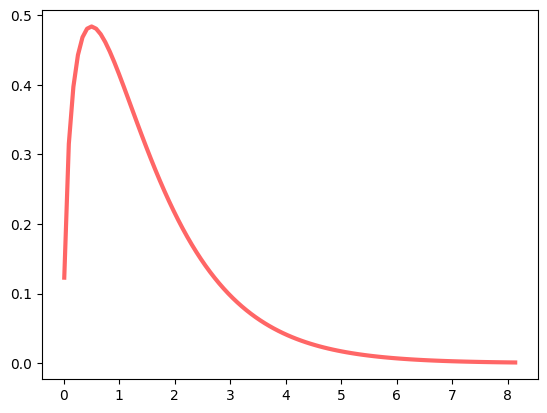

In [ ]:
a = 1.5
x = np.linspace(S.gamma.ppf(0.001, a),
                S.gamma.ppf(0.999, a), 100)

plt.plot(x, S.gamma.pdf(x, a),
       'r-', lw=3, alpha=0.6, label='gamma pdf')

In [ ]:
(lambda: S.gamma(1).rvs())()

np.float64(1.454977024682279)

In [ ]:
#| export
import numpy as np
from scipy.stats import norm, gamma as sp_gamma, uniform as sp_uniform

class Distribution:
    def __call__(self):
        raise NotImplementedError
    
    def pdf(self, xs=None, n=10000):
        import matplotlib.pyplot as plt
        samples = [self() for _ in range(n)]
        xs = xs or np.linspace(min(samples), max(samples), 200)
        density, bins = np.histogram(samples, bins=xs, density=True)
        plt.plot(bins[:-1], density)
        plt.show()

    def __add__(self, other):
        return Add(self, other)

    def __sub__(self, other):
        other = other if isinstance(other, Distribution) else Constant(other)
        return Add(self, Negate(other))

    def __rsub__(self, other):
        other = other if isinstance(other, Distribution) else Constant(other)
        return Add(other, Negate(self))
    
    def __mul__(self, other):
        return Mul(self, other)

class ScipyDist(Distribution):
    def __init__(self, dist_fn, *args, **kwargs):
        self.dist = dist_fn(*args, **kwargs)

    def __call__(self):
        return self.dist.rvs()

class Add(Distribution):
    def __init__(self, a, b):
        self.a = a if isinstance(a, Distribution) else Constant(a)
        self.b = b if isinstance(b, Distribution) else Constant(b)

    def __call__(self):
        return self.a() + self.b()

class Mul(Distribution):
    def __init__(self, a, b):
        self.a = a if isinstance(a, Distribution) else Constant(a)
        self.b = b if isinstance(b, Distribution) else Constant(b)

    def __call__(self):
        return self.a() * self.b()
    
class Negate(Distribution):
    def __init__(self, dist):
        self.dist = dist if isinstance(dist, Distribution) else Constant(dist)

    def __call__(self):
        return -self.dist()

class Constant(Distribution):
    def __init__(self, value):
        self.value = value

    def __call__(self):
        return self.value

class Clip(Distribution):
    def __init__(self, dist, *, low=None, high=None):
        self.dist = dist if isinstance(dist, Distribution) else Constant(dist)
        self.low = low
        self.high = high

    def __call__(self):
        val = self.dist()
        if self.low is not None:
            val = max(self.low, val)
        if self.high is not None:
            val = min(self.high, val)
        return val

class Quantise(Distribution):
    def __init__(self, dist, levels):
        self.dist = dist
        self.levels = np.array(list(levels))

    def __call__(self):
        val = self.dist()
        return self.levels[np.abs(self.levels - val).argmin()]

# Aliases
def normal(mu=0, sigma=1): return ScipyDist(norm, mu, sigma)
def gamma(alpha, scale=1): return ScipyDist(sp_gamma, alpha, scale=scale)
def uniform(low=0, high=1): return ScipyDist(sp_uniform, loc=low, scale=high - low)

def clip(d, *, low=None, high=None):
    return Clip(d, low=low, high=high)

def quant(d, levels): return Quantise(d, levels)

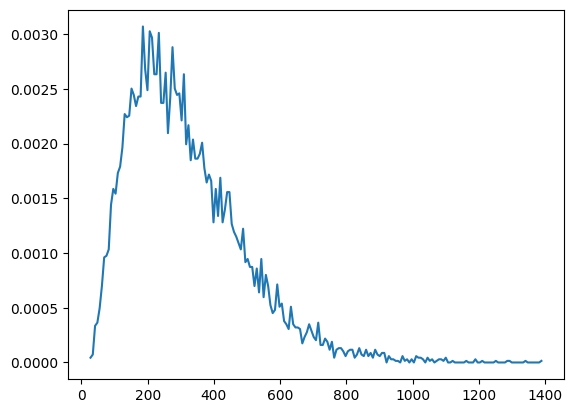

In [ ]:
(gamma(3) * 100 + 20).pdf()

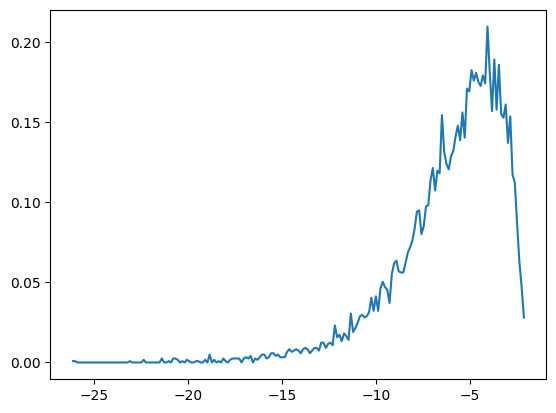

In [ ]:
(gamma(2) * -2 - 2).pdf()

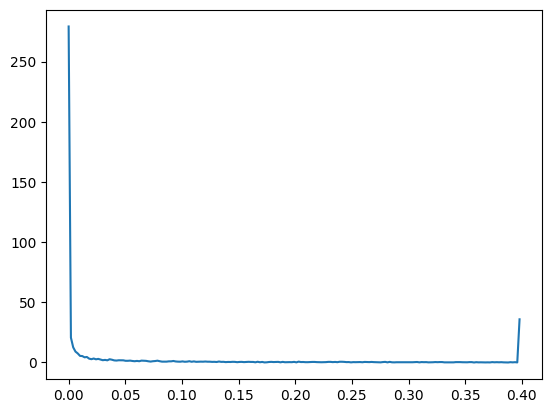

In [ ]:
clip(gamma(0.1), high=0.4).pdf()

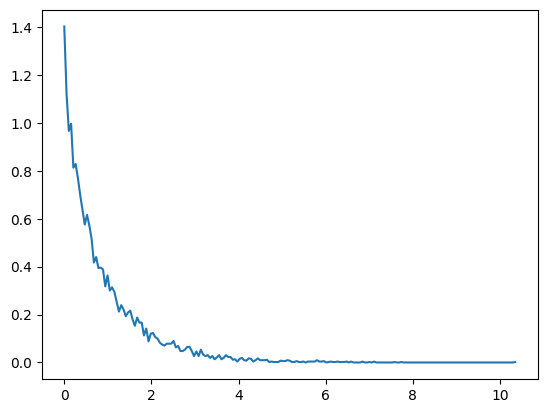

In [ ]:
gamma(0.9).pdf()

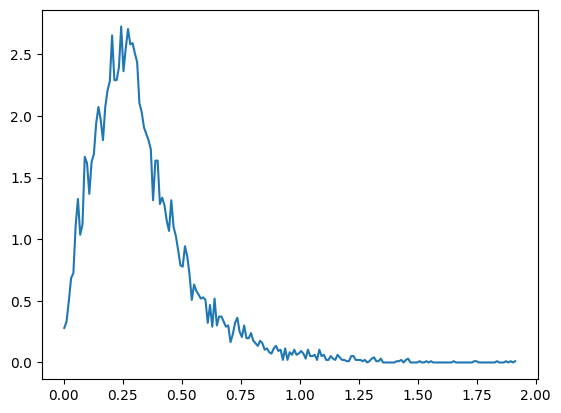

In [ ]:
(uniform(0, 0.3) + clip(gamma(0.9) * 0.2, high=4)).pdf()

In [ ]:
tonegen = RandomToneGen(
    gamma(3) * 100 + 20,
    gamma(2) * -2 - 2,
    uniform(0, 0.3) + clip(gamma(0.9) * 0.2, high=4),
    uniform(0.05, 0.6),
    uniform(),
    uniform(0.05, 1)
)

[<matplotlib.lines.Line2D>]

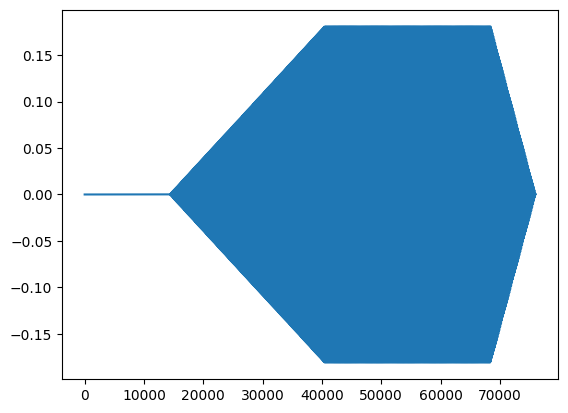

In [ ]:
plt.plot(list(tonegen()))